In [34]:
import torch

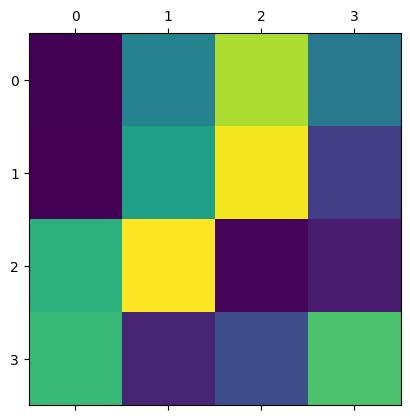

In [35]:
from matplotlib import pyplot as plt
import numpy as np

def generate_W(n: int):

    W = np.random.random((n, n))
    w_sum = np.sum(W, axis=1, keepdims=True)
    return W / w_sum


n = 4
W = generate_W(n)

plt.matshow(W)

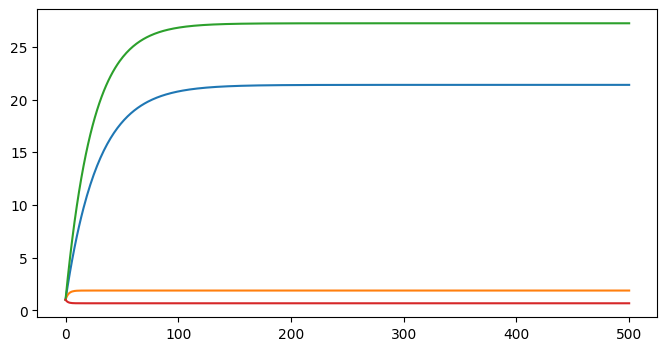

In [36]:
def step(P: np.ndarray, W: np.ndarray):

    new_P = np.zeros_like(P)
    W = np.copy(W)
    np.fill_diagonal(W, 0)

    outgoing = np.sum(W, axis=1)
    incoming = np.sum(W, axis=0)

    for i_classifier, (Pi, inc, out) in enumerate(zip(P, incoming, outgoing, strict=True)):
        new_P[i_classifier] = out * (Pi + inc)

    return new_P


def solve(P0: np.ndarray, W: np.ndarray, steps: int):

    Ps = [P0]
    P = P0
    for _ in range(steps):
        P = step(P, W)
        Ps.append(P)

    return np.array(Ps)


P0 = np.ones(n)
Ps = solve(P0, W, 500)

fig, ax  = plt.subplots(figsize=(8, 4))

for i_classifier in range(Ps.shape[1]):
    ax.plot(Ps[:, i_classifier])

In [37]:
def generate_W(n: int):

    W = np.random.random((n, n))
    w_sum = np.sum(W, axis=1, keepdims=True)
    return W / w_sum


def generate_W_w(n: int):
    # Sample intrinsic self-vote weights for each voter
    alphas = np.random.rand(n)  # α_i in [0,1] for each voter i

    # Initialize a matrix for delegation probabilities.
    # For each voter j, we will generate a probability distribution over all i ≠ j.
    p = np.zeros((n, n))
    for j in range(n):
        # Get indices for "other" voters (excluding self)
        others = [i for i in range(n) if i != j]
        # Generate random positive numbers for these indices
        rand_vals = np.random.rand(len(others))
        # Normalize so that they sum to 1
        p[j, others] = rand_vals / rand_vals.sum()

    # Now, each voter j delegates a fraction (1 - α_j) of their vote according to p[j, :].
    # In our fixed point equation, we want:
    #   x_i = α_i + Σ_j (1-α_j)*p[j, i] * x_j.
    # So define a matrix M where M[j, i] = (1-α_j)*p[j, i].
    M = (1 - alphas)[:, np.newaxis] * p  # shape (n, n)

    # For the fixed point equation in the form x = w + W x, we want W[i, j]
    # to represent the delegation contribution from voter j to voter i.
    # That is, we set:
    #    W[i, j] = (1-α_j)*p[j, i]   <=>   W = M^T.
    W = M.T

    # Return W and the intrinsic weights vector (w = alphas)
    return W, alphas

n = 4
W, w = generate_W_w(n)

def solve_fixed_point(W: np.ndarray, w: np.ndarray):

    W = np.copy(W.T)
    np.fill_diagonal(W, 0)
    stable = np.linalg.pinv(np.identity(W.shape[0]) - W) @ w[:, np.newaxis]

    return np.squeeze(stable)

solve_fixed_point(W, w)

array([1., 1., 1., 1.])

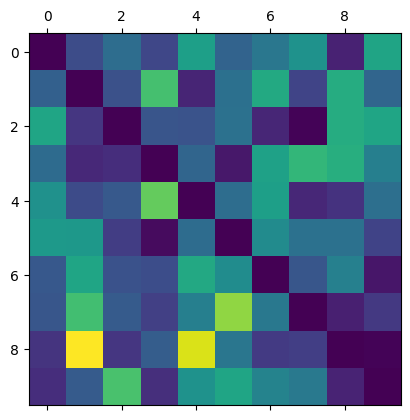

In [38]:
def generate_W_p(n: int):

    W = np.random.random((n, n))
    w_sum = np.sum(W, axis=1, keepdims=True)
    W =  W / w_sum

    p = np.diag(np.copy(W))
    np.fill_diagonal(W, 0)

    return W, p

W, p = generate_W_p(10)
plt.matshow(W)

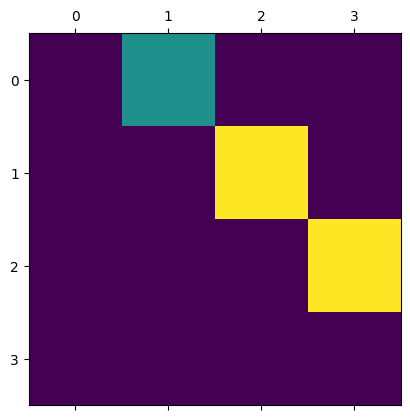

In [39]:
W = np.array([
    [0, 0.5, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1],
    [0, 0, 0, 1],
], dtype=float)

p = np.ones(W.shape[0])
np.fill_diagonal(W, 0.0)

plt.matshow(W)

In [ ]:
import numpy as np

def step(p: np.ndarray, W: np.ndarray):
    out = np.sum(W, axis=1)
    incoming = np.dot(W.T, p)
    new_p = (1 - out) * p + incoming
    return new_p

def solve_iterative(W: np.ndarray, p: np.ndarray, iterations: int = 100):
    for _ in range(iterations):
        p = step(p, W)
    return p

print(solve_iterative(W, p))


[7.88860905e-31 7.88860905e-31 1.57772181e-30 4.00000000e+00]


In [41]:
import numpy as np
import matplotlib.pyplot as plt

def step(p_delegatable, p_kept, W):
    n = len(p_delegatable)

    new_delegatable = np.zeros_like(p_delegatable)
    new_kept = p_kept.copy()

    outgoing_sums = np.sum(W, axis=1) - np.diag(W)

    keep_amount = np.diag(W) * p_delegatable
    outflow = p_delegatable - keep_amount

    new_kept += keep_amount

    # Distribute the outflow to other voters proportionally:
    for i in range(n):
        outgoing_sum = outgoing_sums[i]
        if outgoing_sum > 0:
            # If there's some fraction going out, distribute among j != i
            for j in range(n):
                if (j == i) or W[i, j] <= 0:
                    continue

                frac = W[i,j] / outgoing_sum
                incoming_j = frac * outflow[i]
                new_delegatable[j] += incoming_j
        else:
            # If row_sums_offdiag[i] == 0, then i doesn't delegate to others
            # (maybe i is a 'full sink' => W[i,i] = 1 or the row is all 0)
            # so i effectively keeps all leftover
            new_kept[i] += outflow[i]

    return new_delegatable, new_kept

import numpy as np

def vectorized_step(p_delegatable, p_kept, W):

    keep_amount = np.diag(W) * p_delegatable
    outflow = p_delegatable - keep_amount

    new_kept = p_kept + keep_amount

    # In torch Small positive constant is added to ensure there is always some delegations
    outgoing_sums = np.sum(W, axis=1) - np.diag(W)

    # This doesn't exist in the torch version
    # TODO inspect what it does in
    no_delegate = (outgoing_sums == 0)
    new_kept[no_delegate] += outflow[no_delegate]

    W_eff = W.copy()
    np.fill_diagonal(W_eff, 0)

    # This is deleted in torch since softmax is always positive
    W_eff[W_eff <= 0] = 0

    # This is deleted in torch since outgoing_sums is always positive
    denom = np.where(outgoing_sums > 0, outgoing_sums, 1)

    contribution = (W_eff / denom[:, None]) * outflow[:, None]

    new_delegatable = contribution.sum(axis=0)

    return new_delegatable, new_kept



import torch

def torch_step(p_delegatable, p_kept, W):

    diag_indices = torch.arange(n)

    # Get the diagonal elements of W: shape (batch_size, n)
    diag_W = W[:, diag_indices, diag_indices]

    # Compute the amount to keep
    keep_amount = diag_W * p_delegatable
    outflow = p_delegatable - keep_amount
    new_kept = p_kept + keep_amount

    # Sum each row of W and subtract the diagonal, adding a small epsilon for stability.
    outgoing_sums = W.sum(dim=2) - diag_W + 1e-6

    # Create an effective W with zeros on the diagonal.
    mask = torch.ones_like(W)
    mask[:, diag_indices, diag_indices] = 0

    W_eff = W * mask

    # Normalize each row of W_eff by its outgoing sum and weight by the outflow.
    # W_eff: (batch, n, n), outgoing_sums.unsqueeze(2): (batch, n, 1), outflow.unsqueeze(2): (batch, n, 1)
    contribution = (W_eff / outgoing_sums.unsqueeze(2)) * outflow.unsqueeze(2)

    # Sum contributions over the rows to get the new delegatable values (for each target node).
    new_delegatable = contribution.sum(dim=1)

    return new_delegatable, new_kept


def solve_iterative(W, p_init, step_fun, max_iter=1000, tol=1e-4):

    p_delegatable = p_init.astype(float).copy()
    p_kept = np.zeros_like(p_delegatable)

    for i_iter in range(max_iter):
        old_sum = p_delegatable.sum() + p_kept.sum()

        new_delegatable, new_kept = step_fun(p_delegatable, p_kept, W)
        new_sum = new_delegatable.sum() + new_kept.sum()

        # Check that total power is conserved (up to float epsilon)
        if not np.isclose(old_sum, new_sum, atol=1e-9):
            print(f"Warning: total power changed from {old_sum} to {new_sum}")

        # Check for convergence
        if (np.allclose(new_delegatable, p_delegatable, atol=tol) and
            np.allclose(new_kept, p_kept, atol=tol)):
            # print("Converged", i_iter)
            return new_delegatable + new_kept

        p_delegatable, p_kept = new_delegatable, new_kept

    return p_delegatable + p_kept


def solve_iterative_torch(W, max_iter=100, tol=1e-4):

    p_delegatable = torch.ones((W.shape[0], W.shape[1]), device="cuda", dtype=torch.double)
    p_kept = torch.zeros_like(p_delegatable)

    for i_iter in range(max_iter):
        old_sum = p_delegatable.sum() + p_kept.sum()

        new_delegatable, new_kept = torch_step(p_delegatable, p_kept, W)
        new_sum = new_delegatable.sum() + new_kept.sum()

        if not torch.isclose(old_sum, new_sum, atol=1e-6):
            print(f"Warning: total power changed from {old_sum.item()} to {new_sum.item()}")

        if (torch.allclose(new_delegatable, p_delegatable, atol=tol) and
            torch.allclose(new_kept, p_kept, atol=tol)):
            # print("Converged", i_iter)
            return new_delegatable + new_kept

        p_delegatable, p_kept = new_delegatable, new_kept

    return p_delegatable + p_kept


W = np.array([
    [0.0, 1.0, 0.0, 0.0],
    [0.0, 0.0, 1.0, 0.0],
    [1.0, 0.0, 0.0, 0.0],
    [0.0, 0.5, 0.0, 0.5],
])


n = 4
W = np.random.random((n, n))
w_sum = np.sum(W, axis=1, keepdims=True)
W =  W / w_sum

# plt.matshow(W)

p_init = np.array([1,1,1,1], dtype=float)
p_vector = solve_iterative(W, p_init, vectorized_step)
p_init = np.array([1,1,1,1], dtype=float)
p_loop = solve_iterative(W, p_init, step)

W_torch = torch.tensor(W, device="cuda", dtype=torch.double, requires_grad=True).unsqueeze(0)
p_torch = solve_iterative_torch(W_torch)
p_torch = torch.squeeze(p_torch).detach().cpu().numpy()
delta = np.abs(p_torch - p_loop)

print(p_loop, p_torch)
print(np.max(delta), np.mean(delta))
# np.max(np.abs((p_vector_del + p_vector_kept) - (p_loop_del + p_loop_kept)))

# print("Final delegatable =", p_delegatable_final)
# print("Final kept        =", p_kept_final)
# print("\nFinal             =", p_kept_final  + p_delegatable_final)
# print("Total power       =", p_delegatable_final.sum() + p_kept_final.sum())


[1.74232965 0.53987893 1.10013563 0.6176558 ] [1.74232251 0.53987679 1.100132   0.6176534 ]
7.140426472984629e-06 3.825456028033747e-06


In [42]:
W_torch = torch.tensor(W, device="cuda", dtype=torch.double, requires_grad=True)
p_torch = solve_iterative_torch(W_torch.unsqueeze(0), tol=1e-5)

p_torch[:, 0].sum().backward()
W_torch.grad

tensor([[ 3.0657,  0.1649, -0.5945,  0.0193],
        [ 0.3731, -1.9500, -0.8393, -0.3829],
        [ 0.3156, -0.1407, -1.3207, -0.2169],
        [ 0.4095, -0.2024, -0.7355, -1.7845]], device='cuda:0',
       dtype=torch.float64)

In [43]:
l = torch.rand((3, 4, 4))
diag = torch.arange(4)
print(l)
l[:, diag, diag]

tensor([[[0.4129, 0.8620, 0.9980, 0.0152],
         [0.7580, 0.4858, 0.1426, 0.7280],
         [0.0828, 0.3038, 0.7248, 0.4703],
         [0.0573, 0.9319, 0.9924, 0.9836]],

        [[0.6695, 0.8760, 0.4110, 0.5208],
         [0.9012, 0.6748, 0.8321, 0.3026],
         [0.0256, 0.4344, 0.6823, 0.1051],
         [0.0202, 0.2089, 0.5909, 0.0293]],

        [[0.4355, 0.9853, 0.2838, 0.2508],
         [0.4070, 0.5063, 0.4563, 0.2391],
         [0.9170, 0.0908, 0.2101, 0.4987],
         [0.5536, 0.2023, 0.5558, 0.3273]]])


tensor([[0.4129, 0.4858, 0.7248, 0.9836],
        [0.6695, 0.6748, 0.6823, 0.0293],
        [0.4355, 0.5063, 0.2101, 0.3273]])

In [13]:
import numpy as np

def build_layers(layers: int, body: float, classification: float, delegation: float, width: int = 50) -> tuple[int, int, list[int], list[int], list[int]]:

    weights = np.array([body, classification, delegation])
    weights = weights / weights.sum()

    l = np.round(layers * weights).astype(int)

    def to_layers(l: int) -> list:
        return [width for _ in range(l)]

    lb, lc, ld = l
    b = to_layers(lb)
    c = to_layers(lc)
    d = to_layers(ld)

    return layers - l.sum(), b, c, d,

build_layers(72 // 4, 1, 1, 4, width=20)



(np.int64(0),
 [20, 20, 20],
 [20, 20, 20],
 [20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20])

In [4]:
layer_step = 3 * 4
up_to = 8
ls = list(range(layer_step, layer_step * (up_to + 1), layer_step))

for layer in ls:
    layer = layer // 4
    _, b, c, d = build_layers(layer, 1, 1, 1, width=10)
    print(len(b), len(c), len(d))


1 1 1
2 2 2
3 3 3
4 4 4
5 5 5
6 6 6
7 7 7
8 8 8


In [197]:
ratios_specs = list(itertools.permutations([1, 1, 2]))
ratios_specs += list(itertools.permutations([1, 1, 4]))
ratios_specs += list(itertools.permutations([2, 1, 2]))
ratios_specs += list(itertools.permutations([4, 1, 4]))
ratios_specs.append((1, 1, 1))

ratios_specs = list(set(ratios_specs))
ratios_specs

[(1, 2, 1),
 (2, 1, 1),
 (1, 4, 4),
 (4, 1, 4),
 (4, 1, 1),
 (4, 4, 1),
 (1, 1, 2),
 (1, 2, 2),
 (2, 1, 2),
 (2, 2, 1),
 (1, 1, 4),
 (1, 1, 1),
 (1, 4, 1)]

In [214]:
[f"{v:.2f}" for v in  np.linspace(0.0, 1.0, num=11, endpoint=True)]

['0.00',
 '0.10',
 '0.20',
 '0.30',
 '0.40',
 '0.50',
 '0.60',
 '0.70',
 '0.80',
 '0.90',
 '1.00']

In [44]:
def generate_main_tasks(n_tasks: int = 4, per_task: int = 2):

    fs = np.random.uniform(2.0, 10.0, (n_tasks, 1, per_task))
    os = np.random.uniform(-np.pi, np.pi, (n_tasks, 1, per_task))

    tasks = np.concatenate((fs, os), axis=1)

    return tasks

generate_main_tasks().tolist()

[[[6.0774832942520245, 3.550324508378714],
  [2.0621926327996247, 2.32336777014386]],
 [[9.919197924132327, 4.370991503681554],
  [0.24246156691589382, -1.1042233435451796]],
 [[9.619927931523401, 3.2751398619749503],
  [1.564707231973645, -0.6347579189092225]],
 [[9.047542464093993, 5.687937477082378],
  [-2.5304145583400803, -2.5424225511443423]]]

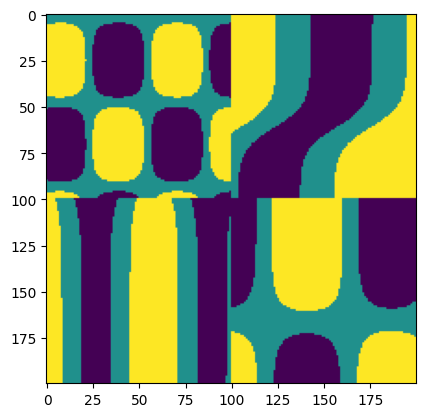

In [45]:
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

main_tasks = np.array([[[9.932413069162699, 4.519830328319423],
  [-0.8168586112347911, 3.0652076063204268]],
 [[6.813502941134584, 4.535151023517105],
  [-0.9787248160055277, -0.7607226180909064]],
 [[5.072345710065466, 8.097182426210178],
  [0.13002298321802952, -0.9435734256299448]],
 [[9.888464240328421, 6.869020754016834],
  [1.1026867568371523, 0.13987090946831815]]])


def generate_main_tasks(n_tasks: int = 4, per_task: int = 2):
    fs = np.random.uniform(2.0, 10.0, (n_tasks, 1, per_task))
    os = np.random.uniform(-np.pi, np.pi, (n_tasks, 1, per_task))
    tasks = np.concatenate((fs, os), axis=1)
    return tasks

def _sample(x: np.ndarray, y: np.ndarray, tasks: np.ndarray | None = None) -> np.ndarray:
    if tasks is None:
        tasks = main_tasks.copy()

    F = 0
    O = 1
    quantiles = [1/3, 2/3]

    z = np.full_like(x, -1, dtype=float)
    c = np.full_like(x, -1, dtype=int)

    mask_ul = (x < 0) & (y > 0)
    mask_ur = (x >= 0) & (y > 0)
    mask_ll = (x < 0) & (y <= 0)
    mask_lr = (x >= 0) & (y <= 0)

    if (not mask_ul.any()) or (not mask_ur.any()) or (not mask_ll.any()) or (not mask_lr.any()):
        raise ValueError("Some quadrant has 0 values")

    def fill_classes(mask: np.ndarray):
        t1, t2 = np.quantile(z[mask], quantiles)
        c_masked = c[mask]
        c_masked[:] = 0
        c_masked[z[mask] > t1] = 1
        c_masked[z[mask] > t2] = 2
        c[mask] = c_masked
        return c

    # Upper Left quadrant (x < 0, y > 0)
    dx = x[mask_ul] + 0.5
    dy = y[mask_ul] - 0.5
    z[mask_ul] = np.cos(dx * tasks[0, F, 0] + tasks[0, O, 0]) \
                + np.tanh(dy * tasks[0, F, 1] + tasks[0, O, 1])
    c = fill_classes(mask_ul)

    # Upper Right quadrant (x >= 0, y > 0)
    dx = x[mask_ur] - 0.5
    dy = y[mask_ur] - 0.5
    z[mask_ur] = np.sin(dx * tasks[1, F, 0] + tasks[1, O, 0]) \
                * np.tanh(dy * tasks[1, F, 1] + tasks[1, O, 1])
    c = fill_classes(mask_ur)

    # Lower Right quadrant (x >= 0, y <= 0)
    dx = x[mask_lr] + 0.5
    dy = y[mask_lr] + 0.5
    z[mask_lr] = np.sin(dx * tasks[2, F, 0] + tasks[2, O, 0] \
                + np.tanh(dy * tasks[2, F, 1] + tasks[2, O, 1]))
    c = fill_classes(mask_lr)

    # Lower Left quadrant (x < 0, y <= 0)
    dx = x[mask_ll] + 0.5
    dy = y[mask_ll] + 0.5
    z[mask_ll] = np.tanh(
        np.cos(dx * tasks[3, F, 0] + tasks[3, O, 0]) \
        * np.sin(dy * tasks[3, F, 1] + tasks[3, O, 1])
    )
    c = fill_classes(mask_ll)

    X = np.empty((x.size, 2))
    # X[:, 0] = x
    # X[:, 1] = y

    return X, c


x, y = np.linspace(-1, 1, 200), np.linspace(-1, 1, 200)

X, Y = np.meshgrid(x, y)
_, Z = _sample(X, Y)


plt.imshow(Z)




In [46]:
import asyncio

l = asyncio.Queue()

l.__len

AttributeError: 'Queue' object has no attribute '__len'

In [ ]:
8*16

128

In [68]:
import numpy as np
import itertools

def total_params(b, c, d, width):
    one = width ** 2
    return b* one, c * one, d * one


def build_layers(params: int, body: float, classification: float, delegation: float, width: int = 50) -> tuple[int, list[int], list[int], list[int]]:


    weights = np.array([body, classification, delegation])
    weights = weights / weights.sum()

    p = np.floor(weights * params).astype(int)

    best_found_cost = float("inf")
    best_found = None
    best_found_params = None

    for cand_layers in itertools.product(range(1, 20), repeat=3):
        candidate_b, candidate_c, candidate_d  = cand_layers
        cand_params = total_params(candidate_b, candidate_c, candidate_d, width=width)

        cost = np.abs(p - np.array(cand_params)).sum()

        if cost < best_found_cost:
            best_found = cand_layers
            best_found_cost = cost
            best_found_params = cand_params


    def to_layers(l: int) -> list:
        return [width for _ in range(l)]

    lb, lc, ld = best_found
    b = to_layers(lb)
    c = to_layers(lc)
    d = to_layers(ld)

    return sum(best_found_params), b, c, d

build_layers(params=57142 // 4, body=1, classification=1, delegation=1, width=30)

(13500, [30, 30, 30, 30, 30], [30, 30, 30, 30, 30], [30, 30, 30, 30, 30])

In [73]:
# Mammba out
patch_size = 16 ** 2
medium_size = 224 ** 2
D = 384
L = medium_size / patch_size

img_ratio = L / (6 * D)

L, D, img_ratio

(196.0, 384, 0.08506944444444445)

In [ ]:
# Point
patch_size = 32
medium_size = 2048
D = 384
L = medium_size / patch_size
point_raio = L / (6 * D)

L, D, point_raio

(64.0, 384, 0.027777777777777776)

In [ ]:
# Video
patch_size = 2 * 16 * 16
medium_size = 32 * 240 * 420
D = 384
L = medium_size / patch_size
video_ratio = L / (6 * D)

L, D, video_ratio

(6300.0, 384, 2.734375)

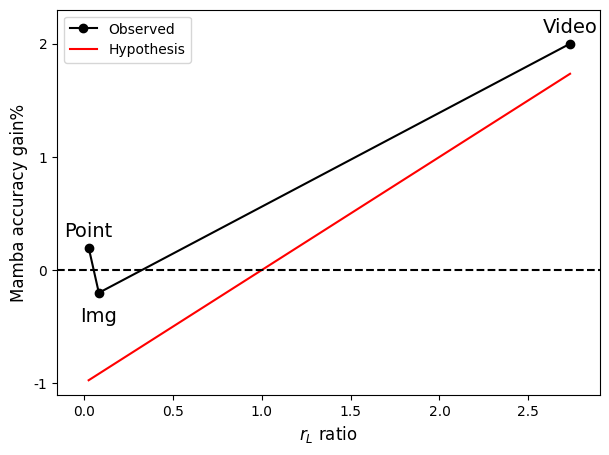

In [179]:
from matplotlib import pyplot as plt

video_mamba_a = 71.4
video_trans_a = 69.4

point_mamba_a = 93.6000
point_trans_a = 93.4000

img_mamba_a = 85.3
img_trans_a = 85.5

data = [[video_mamba_a, video_trans_a], [point_mamba_a, point_trans_a], [img_mamba_a, img_trans_a]]
data = np.array(data)

mins = np.min(data, axis=1, keepdims=True)
maxs = np.max(data, axis=1, keepdims=True)

data = (data - mins)
real_x = np.array([video_ratio, point_raio, img_ratio])

si = np.argsort(real_x)
xlabel = real_x[si]
real_x = real_x[si]
data = data[si, :]

x_hypo = np.linspace(64, 6300.0, 100) / (6 * D)

x = np.arange(3)
labels = ["Point", "Img", "Video"]
xlabel = [f"{v:.3f}\n{d}" for v, d in zip(real_x, labels)]


plt.style.use('default')
linecol = "black"

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(real_x, data[:, 0] - data[:, 1], color=linecol, marker="o", label="Observed")
ax.plot(x_hypo, x_hypo - 1, color="red", label="Hypothesis")

# ax.set_xticks(real_x, xlabel,  fontsize=11)
ax.set_yticks([-1, 0, 1, 2], [-1, 0, 1, 2], fontsize=10)
# ax.set_xticks([0, 1, 2], [0, 1, 2], fontsize=9)
ax.set_ylabel("Mamba accuracy gain%", fontsize=12)
ax.set_xlabel(r"$r_L$ ratio", fontsize=12)
ax.axhline(0, color=linecol, linestyle="dashed")
ax.legend()


for i, (x_val, y_val, label) in enumerate(zip(real_x, data[:, 0] - data[:, 1], labels)):
    offset = 0.05 if label in ["Point", "Video"] else -0.1
    va = "bottom" if label in ["Point", "Video"] else "top"
    ax.annotate(label, (x_val, y_val), textcoords="offset points", xytext=(0, offset * 100), ha="center", va=va, fontsize=14)

ax.set_ylim([-1.1, 2.3])
ax.set_xlim([-0.15, 2.9])
plt.show()


fig.savefig("./black_hypothesis.pdf")

C:\Users\viktor\AppData\Local\Temp\ipykernel_19408\1429281090.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("domain", group_keys=False).apply(quantile_transform)


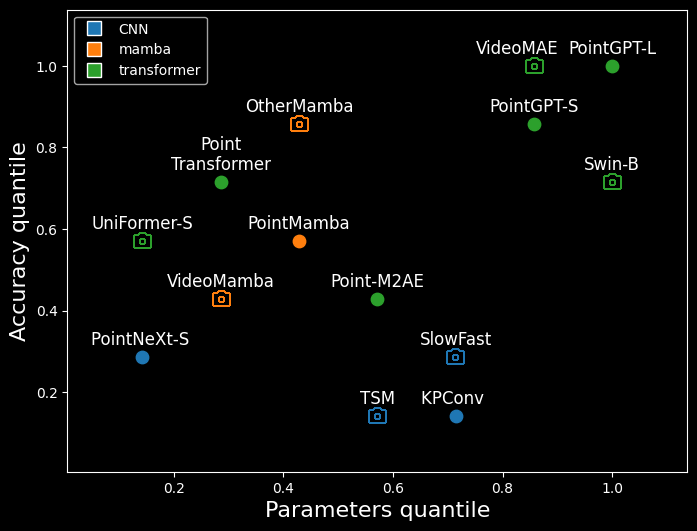

In [ ]:
import pandas as pd
max_lp = 4

samples = [
    ("video", "mamba",  "VideoMamba", 22.8, 64.2),
    ("video", "mamba",  "OtherMamba", 24.2, 71.4),
    ("video", "CNN", "SlowFast", 62.8, 63.1),
    ("video", "transformer", "VideoMAE", 87.3, 74.5),
    ("video", "transformer", "Swin-B", 88.1, 69.6),
    ("video", "transformer", "UniFormer-S", 21.4, 69.4),
    ("video", "CNN", "TSM", 24.3, 61.7),
    ("language", "mamba", "MoE-Mamba", 117, 1 - (2.81 / max_lp)),
    ("language", "transformer", "MoE-Transformer", 114, 1 - (2.88 / max_lp)),
    ("language", "transformer", "Megatron-gpt2", 345, 1 - (2.960 / max_lp)),
    ("point", "transformer", "Point\nTransformer", 4.9, 93.7),
    ("point", "transformer", "Point-M2AE", 12.8, 93.4),
    ("point", "transformer", "PointGPT-L", 360, 94.9),
    ("point", "transformer", "PointGPT-S", 29.2, 94.0),
    ("point", "mamba", "PointMamba", 12.3, 93.6),
    ("point", "CNN", "PointNeXt-S ", 1.4, 93.2),
    ("point", "CNN", "KPConv ", 15, 92.9),
]


df = pd.DataFrame(samples, columns=["domain", "type", "name", "params", "score"])

def quantile_transform(group):
    group["param_quantile"] = group["params"].rank(pct=True)
    group["score_quantile"] = group["score"].rank(pct=True)
    return group

df = df.groupby("domain", group_keys=False).apply(quantile_transform)

import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

offsets = {
    "VideoMAE": (-0.03, 0),
    #"Point\nTransformer": (0.05, -0.08),
}

def plot_models(samples: pd.DataFrame, switch_view=True):
    samples = samples[samples["domain"] != "language"]
    marker_pool = ['o', 's', '^', 'D', 'P', '*', 'X']
    color_pool = plt.cm.tab10.colors

    tasks = sorted(samples["domain"].unique())
    archs = sorted(samples["type"].unique())

    if switch_view:
        color_key = {a: color_pool[i % len(color_pool)] for i, a in enumerate(archs)}
        marker_key = {t: marker_pool[i % len(marker_pool)] for i, t in enumerate(tasks)}
    else:
        color_key = {t: color_pool[i % len(color_pool)] for i, t in enumerate(tasks)}
        marker_key = {a: marker_pool[i % len(marker_pool)] for i, a in enumerate(archs)}

    fig, ax = plt.subplots(figsize=(8, 6))

    image_mapping = {
        "CNN": "./figures/camera_blue.png",
        "mamba": "./figures/camera_orange.png",
        "transformer": "./figures/camera_green.png"
    }

    for idx, row in samples.iterrows():
        if row["domain"] == "video":
            img_file = image_mapping.get(row["type"])
            if img_file:
                img = plt.imread(img_file)
                oi = OffsetImage(img, zoom=0.05)
                ab = AnnotationBbox(oi, (row["param_quantile"], row["score_quantile"]), frameon=False)
                ax.add_artist(ab)
        else:
            color = color_key[row["type"]] if switch_view else color_key[row["domain"]]
            marker = marker_key[row["domain"]] if switch_view else marker_key[row["type"]]
            ax.scatter(row["param_quantile"], row["score_quantile"], color=color, marker=marker, s=80)
        offset = offsets.get(row["name"], (0, 0))
        ax.annotate(row["name"], (row["param_quantile"] + offset[0], row["score_quantile"] + offset[1] + 0.02),
                    textcoords="offset points", xytext=(0, 3), ha='center', fontsize=12)

    ax.set_xlabel("Parameters quantile", fontsize=16)
    ax.set_ylabel("Accuracy quantile", fontsize=16)

    xlims = ax.get_xlim()
    xs = xlims[1] - xlims[0]
    o = 0.1
    ax.set_xlim(xlims[0] - o * xs, xlims[1] + o * xs)

    ylims = ax.get_ylim()
    ys = ylims[1] - ylims[0]
    ax.set_ylim(ylims[0] - o * ys, ylims[1] + o * ys)

    color_labels = archs if switch_view else tasks
    marker_labels = tasks if switch_view else archs
    color_legend = [plt.Line2D([0], [0], marker='s', color='w',
                               label=label, markerfacecolor=color_key[label], markersize=10,  linestyle='None')
                    for label in color_labels]
    # marker_legend = [plt.Line2D([0], [0], marker=marker_key[label], color='k',
    #                             label=label, linestyle='None', markersize=10)
    #                  for label in marker_labels]
    ax.legend(handles=color_legend)

    fig.savefig("./black_scaling.pdf")

    plt.show()

plot_models(df, switch_view=True)

In [ ]:
layers = (np.linspace(10_000, 120_000, num=8, endpoint=True) / 4).astype(int)

for param in layers:
    p, b, c, d = build_layers(param, body=1, classification=1, delegation=1, width=30)
    print(p, len(b), len(c), len(d))

2700 1 1 1
5400 2 2 2
10800 4 4 4
13500 5 5 5
18900 7 7 7
21600 8 8 8
27000 10 10 10
29700 11 11 11


In [66]:
l = list(itertools.permutations([1, 1, 2]))
l += list(itertools.permutations([1, 1, 4]))
l += list(itertools.permutations([2, 1, 2]))
l += list(itertools.permutations([4, 1, 4]))
l.append((1, 1, 1))

rs = list(set(l))

rs

[(1, 2, 1),
 (2, 1, 1),
 (1, 4, 4),
 (4, 1, 4),
 (4, 1, 1),
 (4, 4, 1),
 (1, 1, 2),
 (1, 2, 2),
 (2, 1, 2),
 (2, 2, 1),
 (1, 1, 4),
 (1, 1, 1),
 (1, 4, 1)]

In [53]:
len(list(itertools.product(rs, [1, 2])))

26

In [36]:
set(itertools.permutations([2, 1, 2]))

{(1, 2, 2), (2, 1, 2), (2, 2, 1)}

In [296]:
p = np.array([25000, 12500, 12500])
cand_params = total_params(10, 5, 5, 50)
cost = np.abs(p - np.array(cand_params)).sum()
cost

np.int64(0)

In [243]:
l = itertools.combinations_with_replacement(list(range(1, 5)), 3)
list(l)

[(1, 1, 1),
 (1, 1, 2),
 (1, 1, 3),
 (1, 1, 4),
 (1, 2, 2),
 (1, 2, 3),
 (1, 2, 4),
 (1, 3, 3),
 (1, 3, 4),
 (1, 4, 4),
 (2, 2, 2),
 (2, 2, 3),
 (2, 2, 4),
 (2, 3, 3),
 (2, 3, 4),
 (2, 4, 4),
 (3, 3, 3),
 (3, 3, 4),
 (3, 4, 4),
 (4, 4, 4)]

In [ ]:

total_params()

In [ ]:
10 * 10 * 2 + 10 * 2 * 10 * 4 + 10 * 4 * 10 * 8

4200

In [ ]:

import torch
from matplotlib import pyplot as plt

def solve_delegation_one_sink(Ds, epsilon: float = 0.01):

    # Create a delegation matrix where the columns are the preferences
    # d (batch, n)
    # (batch, n, 1)
    Ds_cat_ready = [torch.unsqueeze(d, 1) for d in Ds]
    D = torch.cat(Ds_cat_ready, dim=1)
    n_batch, n, _ = D.shape

    # Extend the delegation matrix to include the additional agent (agent n+1)
    # For agents 1..n, redefine preferences as ((1 - epsilon)*x_i, epsilon)
    # For the new agent, set its preference to (0, ..., 0, 1)
    D_ext = torch.zeros((n_batch, n + 1, n + 1), dtype=D.dtype, device=D.device)
    # For original agents: scale the old delegation preferences and add epsilon to the new column.
    D_ext[:, :n, :n] = (1 - epsilon) * D
    D_ext[:, n, :n] = epsilon
    D_ext[:, n, n] = 1.0

    # Extract the power the model wants to keep for itself
    # p = torch.diagonal(D, dim1=-2, dim2=-1)
    # p_column = p.unsqueeze(-1)
    # Everybody gets one vote
    p_column = torch.ones((n_batch, n + 1, 1), dtype=D.dtype, device=D.device)

    # Remove diagonal
    mask = torch.ones_like(D_ext)
    batch_indices = torch.arange(n_batch).unsqueeze(1).unsqueeze(2)
    diag_indices = torch.arange(n + 1).unsqueeze(0).expand(n + 1, -1)
    mask[batch_indices, diag_indices, diag_indices] = 0
    D_no_diag = D_ext * mask


    # Create identity batch matrix
    # identity = torch.zeros_like(D)
    # identity[batch_indices, diag_indices, diag_indices] = 1
    identity = torch.eye(n + 1, dtype=D.dtype, device=D.device).unsqueeze(0).expand(n_batch, -1, -1)

    # Solve the equation
    inverse = torch.pinverse(identity - D_no_diag)
    power_ext = torch.bmm(inverse, p_column)
    power_ext = torch.squeeze(power_ext, -1)
    power_ext = power_ext * torch.diagonal(D_ext, offset=0, dim1=1, dim2=2).squeeze()

    # Return lost power uniformly back
    print(power_ext[:, [-1]] / n -  1 / n)
    power = torch.clone(power_ext[:, :-1])
    power += power_ext[:, [-1]] / n
    power -= 1 / n

    return power #, torch.transpose(D, 1, 2)


def solve_delegation_many_sinks(
        Ds,
        epsilon: float = 0.01,
        long_delegation_penalty: float = 0.95,
        threshold: float = 0.01
        ):

        # Create a delegation matrix where the columns are the preferences
        # d (batch, n)
        # (batch, n, 1)
        Ds_cat_ready = [torch.unsqueeze(d, 1) for d in Ds]
        D = torch.cat(Ds_cat_ready, dim=1)
        n_batch, n, _ = D.shape
        n2 = 2 * n

        mask = torch.ones((n_batch, n, n), dtype=D.dtype, device=D.device)
        batch_indices = torch.arange(n_batch).unsqueeze(1).unsqueeze(2)
        diag_indices = torch.arange(n).unsqueeze(0).expand(n, -1)
        mask[batch_indices, diag_indices, diag_indices] = 0
        identity = torch.eye(n, dtype=D.dtype, device=D.device).unsqueeze(0).expand(n_batch, -1, -1)


        D_no_diag = D * mask
        self_connections = torch.diagonal(D, offset=0, dim1=1, dim2=2).clone().squeeze()
        # Add small self connection for convergence
        self_connections += epsilon

        D_ext = torch.zeros((n_batch, n2, n2), dtype=D.dtype, device=D.device)
        # Keeep the original connections same without diagonal
        D_ext[:, :n, :n] = D_no_diag

        # The new fake nodes have only self connection
        D_ext[:, n:, n:] = identity

        # Add connections from original nodes to fake nodes
        src_indices = torch.arange(n, device=D.device)
        tgt_indices = src_indices + n
        batch_indices = torch.arange(n_batch, device=D.device).unsqueeze(1).expand(-1, n)
        src_indices = src_indices.unsqueeze(0).expand(n_batch, -1)
        tgt_indices = tgt_indices.unsqueeze(0).expand(n_batch, -1)

        # Flatten all for advanced indexing
        batch_indices = batch_indices.reshape(-1)
        src_indices = src_indices.reshape(-1)
        tgt_indices = tgt_indices.reshape(-1)

        # TODO maybe invert the src and target?
        D_ext[batch_indices, src_indices, tgt_indices] = self_connections

        # Everybody gets one vote except the fake voters
        p_column = torch.ones((n_batch, n2, 1), dtype=D.dtype, device=D.device)
        p_column[:, n:] = 0.0
        acumulated_power = torch.zeros_like(p_column)

        D_ext = torch.transpose(D_ext, 1, 2)
        # Iiterate
        for i in range(1_000):
            acumulated_power += p_column
            new_p = torch.bmm(long_delegation_penalty * D_ext, p_column)
            if torch.allclose(new_p, p_column, atol=threshold):
                p_column = new_p
                print(i)
                break

            p_column = new_p

        power = torch.squeeze(acumulated_power[:, n:])

        if power.ndim == 1:
             power = power.unsqueeze(0)

        power = (power / power.sum(1, keepdim=True)) * n

        return power # , torch.transpose(D, 1, 2)



Ds = [
    torch.tensor([0.5, 0.5, 0], dtype=float).unsqueeze(0),
    torch.tensor([0, 0.5, 0.5], dtype=float).unsqueeze(0),
    torch.tensor([0, 0, 1], dtype=float).unsqueeze(0),
]

p = solve_delegation_many_sinks(Ds, epsilon=0.01, long_delegation_penalty=0.90)
p

28


tensor([[0.5255, 0.7605, 1.7140]], dtype=torch.float64)

In [170]:
D = np.array([
    [0, 1, 0],
    [0, 1, 0],
    [0, 1, 0],
])

np.sum(D, 1)

array([1, 1, 1])

In [174]:


D = np.array([
    [0, 1, 0],
    [0, 1, 0],
    [0, 1, 0],
])

n = D.shape[0]
n2 = n * 2
self_delegation = np.diag(D).copy() + 0.01
np.fill_diagonal(D, 0)
D_ext = np.zeros((n2, n2))
D_ext[:n, :n] = D
D_ext[n:, n:] = np.eye(n)

s = np.arange(n)
t = s + n
D_ext[s, t] = self_delegation

p = np.ones((n2, 1))
p[n:] = 0
P = np.zeros((n2, 1))

T = 0.01
for i in range(10_000):
    P += p
    new_p = (0.95 * D_ext.T) @ p

    if np.allclose(new_p, p, atol=T):
        print(i)
        break
    p = new_p

power = (P)[n:]
power = power / power.sum() * n
power

53


array([[0.01019761],
       [2.97960478],
       [0.01019761]])

In [ ]:
import random
import string

def replace_random_chars(text: str, p: float) -> str:
    if not (0 <= p <= 1):
        raise ValueError("p must be between 0 and 1")

    text_list = list(text)
    non_space_indices = [i for i, char in enumerate(text_list) if char != ' ']
    num_replacements = int(len(non_space_indices) * p)

    for i in random.sample(non_space_indices, num_replacements):
        text_list[i] = random.choice(string.ascii_letters)

    return ''.join(text_list)

# Example usage
text = "How is it possible that you can rexognize this text?"
p = 0.4
modified_text = replace_random_chars(text, p)
print(modified_text)

How iX it possibgz that xog VYz rPxFOniwe jhms tyxtA


In [246]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Button

class InteractiveW:
    def __init__(self, n=4):
        self.n = n
        self.W = np.zeros((n, n))
        self.fig, self.ax = plt.subplots(figsize=(6, 6))
        plt.subplots_adjust(bottom=0.2)
        self.im = self.ax.imshow(self.W, cmap="gray", vmin=0, vmax=1)
        self.ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
        self.ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
        self.ax.grid(which="minor", color="black", linestyle='-', linewidth=2)
        self.ax.tick_params(which="both", bottom=False, left=False, labelbottom=True, labelleft=True)
        self.fig.canvas.mpl_connect("button_press_event", self.onclick)
        button_ax = self.fig.add_axes([0.8, 0.05, 0.15, 0.075])
        self.button = Button(button_ax, "Calculate")
        self.button.on_clicked(self.calculate)
        self.res_ax = self.fig.add_axes([0.1, 0.05, 0.65, 0.075])
        self.res_ax.axis("off")
        self.result_text = self.res_ax.text(0.5, 0.5, "",
                                              horizontalalignment="center",
                                              verticalalignment="center",
                                              transform=self.res_ax.transAxes,
                                              fontsize=12)

    def onclick(self, event):
        # Ensure the click occurred in our matrix axes and that xdata/ydata are defined.
        if event.inaxes != self.ax or event.xdata is None or event.ydata is None:
            return

        # Use rounding to identify the closest cell center
        col = int(np.rint(event.xdata))
        row = int(np.rint(event.ydata))
        if 0 <= row < self.n and 0 <= col < self.n:
            current = self.W[row, col]

            if event.button == 1:
                add = 0.5
            else:
                add = 0.25

            current += add
            if current > 1.0:
                current = 0

            self.W[row, col] = current
            self.im.set_data(self.W)
            self.fig.canvas.draw_idle()

    def calculate(self, event):
        p_init = np.ones(self.n)
        p_delegate, p_kept = solve_iterative(self.W, p_init, solve_iterative)
        p_final = p_kept + p_delegate
        result_str = f"{p_final.sum():.2f} " + np.array2string(p_final, precision=3)
        self.result_text.set_text(result_str)
        self.fig.canvas.draw_idle()

demo = InteractiveW(n=4)
plt.show()


Traceback (most recent call last):
  File "c:\Users\viktor\Documents\liquid\liquid\Lib\site-packages\matplotlib\cbook.py", line 361, in process
    func(*args, **kwargs)
  File "c:\Users\viktor\Documents\liquid\liquid\Lib\site-packages\matplotlib\widgets.py", line 244, in <lambda>
    return self._observers.connect('clicked', lambda event: func(event))
                                                            ^^^^^^^^^^^
  File "C:\Users\viktor\AppData\Local\Temp\ipykernel_14516\1708121637.py", line 54, in calculate
    p_delegate, p_kept = solve_iterative(self.W, p_init, solve_iterative)
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\viktor\AppData\Local\Temp\ipykernel_14516\642333576.py", line 112, in solve_iterative
    new_delegatable, new_kept = step_fun(p_delegatable, p_kept, W)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\viktor\AppData\Local\Temp\ipykernel_14516\642333576.py", line 112, in solv

In [351]:
def solve_fixed_point(W: np.ndarray, p: np.ndarray):

    alpha = 0.9

    W = alpha * np.copy(W.T)
    np.fill_diagonal(W, 0)
    inv = np.linalg.pinv(np.identity(W.shape[0]) - W)
    stable = inv @ (p[:, np.newaxis])

    return np.squeeze(stable)

solve_fixed_point(W, p + np.ones(W.shape[0]))

array([10., 10.,  2.,  2.])

In [ ]:
from torch.distributions import Categorical
import math

n = 12
histogram = torch.bincount(torch.randint(0, n, (100,)))

print(histogram)
dist = Categorical(probs=histogram / histogram.sum())
dist.entropy() / math.log(n)

tensor([ 4,  6, 13, 10, 11, 11,  6,  7,  6,  7, 11,  8])


tensor(0.9793)

In [187]:
import torch

bs = 15
n = 4

Ds = [torch.rand((bs, n), requires_grad=True) for _ in range(n)]
Ds_cat_ready = [torch.unsqueeze(d, -1) for d in Ds]
D = torch.cat(Ds_cat_ready, dim=-1)

p = torch.diagonal(D, dim1=-2, dim2=-1)
mask = torch.ones_like(D)
mask = torch.ones_like(D)
batch_indices = torch.arange(bs).unsqueeze(1).unsqueeze(2)
diag_indices = torch.arange(n).unsqueeze(0).expand(n, -1)
mask[batch_indices, diag_indices, diag_indices] = 0
D_no_diag = D * mask

identity = torch.zeros_like(D)
identity[batch_indices, diag_indices, diag_indices] = 1

p_column = p.unsqueeze(-1)
inverse = torch.pinverse(identity - D_no_diag)
influence = torch.bmm(inverse, p_column)
influence = torch.squeeze(influence)

influence.sum().backward()
Ds[0].grad

tensor([[-2.1357e+00,  3.6265e+00,  1.1176e+00,  3.6910e+00],
        [-8.3647e+00,  6.5824e+00,  2.1243e+00,  6.4119e+00],
        [-1.1760e+00,  8.4928e-01,  1.8983e-01,  7.9119e-01],
        [-2.1929e+00,  8.7414e-01,  7.1433e-01,  1.5521e+00],
        [-2.1542e+00,  2.7343e+00,  2.7598e+00,  3.0652e+00],
        [-1.3913e+00,  1.0445e+00,  1.4449e+00,  7.3552e-01],
        [-2.4541e+01,  3.2504e+02,  3.9021e+02,  6.3721e+02],
        [-1.4137e+00,  1.6525e+00,  1.4320e+00,  5.8267e-01],
        [-5.3871e+00,  2.0789e+01,  1.7634e+01,  1.3988e+01],
        [-1.8161e+01,  1.0851e+02,  5.6026e+01,  7.1462e+01],
        [-1.2609e+00,  1.7677e+00,  6.3777e-01,  1.3811e+00],
        [-2.5434e+00,  4.7205e+00,  5.7598e+00,  7.4937e+00],
        [-8.0925e+01,  5.8892e+02,  6.2427e+02,  8.4758e+02],
        [-5.5893e+00,  1.3715e+01,  7.0365e+00,  6.3492e+00],
        [-3.8388e+00,  3.6738e+00,  6.0307e+00,  4.9316e+00]])

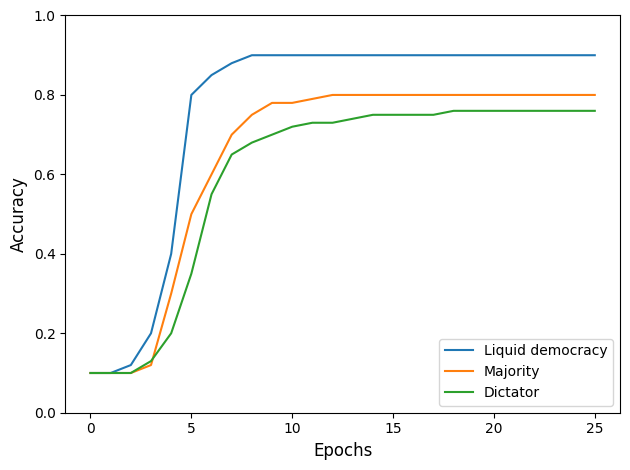

In [6]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(26)
liquid   = [0.1,0.1,0.12,0.2,0.4,0.8,0.85,0.88,0.90,0.90,0.90,0.90,0.90,0.90,0.90,0.90,0.90,0.90,0.90,0.90,0.90,0.90,0.90,0.90,0.90,0.90]
majority = [0.1,0.1,0.10,0.12,0.30,0.50,0.60,0.70,0.75,0.78,0.78,0.79,0.80,0.80,0.80,0.80,0.80,0.80,0.80,0.80,0.80,0.80,0.80,0.80,0.80,0.80]
dictator = [0.1,0.1,0.10,0.13,0.20,0.35,0.55,0.65,0.68,0.70,0.72,0.73,0.73,0.74,0.75,0.75,0.75,0.75,0.76,0.76,0.76,0.76,0.76,0.76,0.76,0.76]

liquid = np.array(liquid)
majority = np.array(majority)
dictator = np.array(dictator)

fig, ax = plt.subplots()

ax.plot(x, liquid,   label='Liquid democracy')
ax.plot(x, majority, label='Majority')
ax.plot(x, dictator, label='Dictator')
ax.set_xlabel("Epochs", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)

ax.set_ylim(0, 1)
ax.legend()

fig.tight_layout()


plt.show()
fig.savefig("./figures/preresults.pdf")
